In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Housing.csv')
df.head()

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [5]:
df.shape

(546, 12)

In [4]:
del df['Unnamed: 0']
df.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     546 non-null    float64
 1   lotsize   546 non-null    int64  
 2   bedrooms  546 non-null    int64  
 3   bathrms   546 non-null    int64  
 4   stories   546 non-null    int64  
 5   driveway  546 non-null    object 
 6   recroom   546 non-null    object 
 7   fullbase  546 non-null    object 
 8   gashw     546 non-null    object 
 9   airco     546 non-null    object 
 10  garagepl  546 non-null    int64  
 11  prefarea  546 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 51.3+ KB


In [7]:
df.isna().sum()

price       0
lotsize     0
bedrooms    0
bathrms     0
stories     0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
garagepl    0
prefarea    0
dtype: int64

In [10]:
df.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [11]:
df['driveway'].value_counts()

driveway
yes    469
no      77
Name: count, dtype: int64

In [12]:
df['recroom'].value_counts()

recroom
no     449
yes     97
Name: count, dtype: int64

In [13]:
df['gashw'].value_counts()

gashw
no     521
yes     25
Name: count, dtype: int64

In [14]:
df.head(2)

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no


In [18]:
x = df[['driveway','recroom','fullbase','gashw','airco','prefarea']]
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in x:
    df[i] = le.fit_transform(df[i])

In [19]:
df.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,1,0,1,0,0,1,0
1,38500.0,4000,2,1,1,1,0,0,0,0,0,0
2,49500.0,3060,3,1,1,1,0,0,0,0,0,0
3,60500.0,6650,3,1,2,1,1,0,0,0,0,0
4,61000.0,6360,2,1,1,1,0,0,0,0,0,0


In [20]:
# Finding the best coorelation for the model
df.corr(numeric_only=True)

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
price,1.000000,0.535796,0.366447,0.516719,0.421190,0.297167,0.254960,0.186218,0.092837,0.453347,0.383302,0.329074
lotsize,0.535796,1.000000,0.151851,0.193833,0.083675,0.288778,0.140327,0.047487,-0.009201,0.221765,0.352872,0.234782
bedrooms,0.366447,0.151851,1.000000,0.373769,0.407974,-0.011996,0.080492,0.097201,0.046028,0.160412,0.139117,0.078953
bathrms,0.516719,0.193833,0.373769,1.000000,0.324066,0.041955,0.126892,0.102791,0.067365,0.184955,0.178178,0.064013
stories,0.421190,0.083675,0.407974,0.324066,1.000000,0.122499,0.042281,-0.173860,0.018261,0.296216,0.043412,0.042940
driveway,0.297167,0.288778,-0.011996,0.041955,0.122499,1.000000,0.091959,0.043428,-0.011942,0.106290,0.203682,0.199378
recroom,0.254960,0.140327,0.080492,0.126892,0.042281,0.091959,1.000000,0.372434,-0.010119,0.136626,0.038122,0.161292
fullbase,0.186218,0.047487,0.097201,0.102791,-0.173860,0.043428,0.372434,1.000000,0.004677,0.045248,0.052524,0.228651
gashw,0.092837,-0.009201,0.046028,0.067365,0.018261,-0.011942,-0.010119,0.004677,1.000000,-0.130350,0.068144,-0.059170
airco,0.453347,0.221765,0.160412,0.184955,0.296216,0.106290,0.136626,0.045248,-0.130350,1.000000,0.156596,0.115626


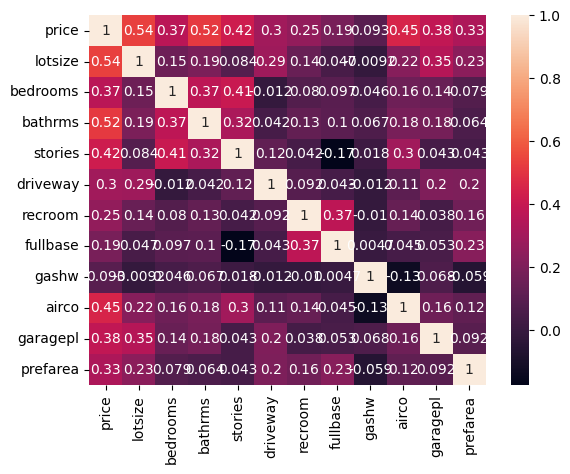

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

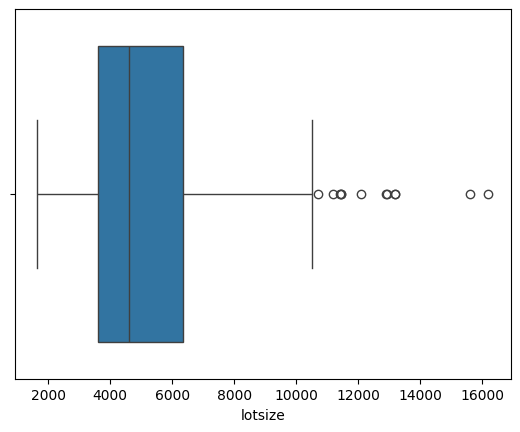

In [22]:
sns.boxplot(x = 'lotsize', data = df)
plt.show()

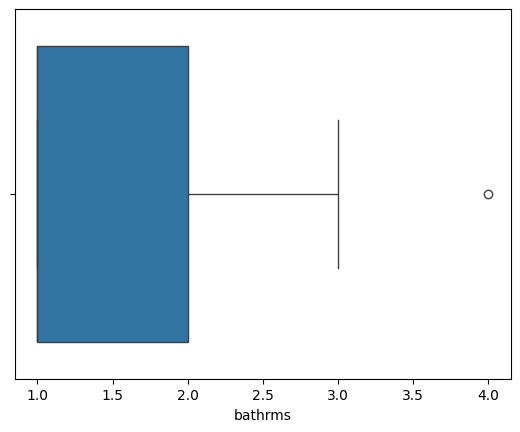

In [23]:
sns.boxplot(x = 'bathrms', data = df)
plt.show()

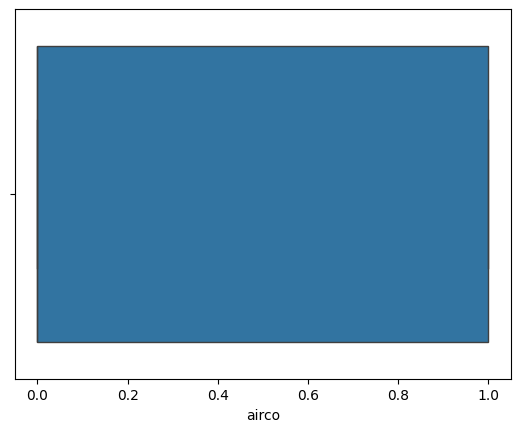

In [24]:
sns.boxplot(x = 'airco', data = df)
plt.show()

In [25]:
df.describe()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.858974,0.177656,0.349817,0.045788,0.316850,0.692308,0.234432
std,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.348367,0.382573,0.477349,0.209216,0.465675,0.861307,0.424032
min,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49125.000000,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62000.000000,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,190000.000000,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


In [26]:
q1 = df['lotsize'].quantile(0.25)
q3 = df['lotsize'].quantile(0.75)
# Calculating the IQR
iqr = q3 - q1
print(f"This is the interquatile range: {iqr}")
lowerbound = q1 - 1.5 * iqr
upperbound = q3 + 1.5 * iqr

print(f"{lowerbound} -- {upperbound}")

outlier = df[(df['lotsize'] < lowerbound) | (df['lotsize'] > upperbound)]
outlier.index

This is the interquatile range: 2760.0
-540.0 -- 10500.0


Index([358, 363, 364, 365, 368, 382, 386, 416, 433, 445, 490, 532], dtype='int64')

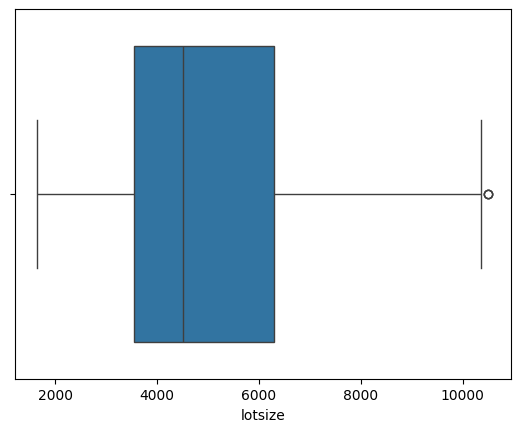

In [27]:
df.drop(outlier.index, inplace=True)
sns.boxplot(x = 'lotsize', data = df)
plt.show()

In [28]:
q1 = df['bathrms'].quantile(0.25)
q3 = df['bathrms'].quantile(0.75)
# Calculating the IQR
iqr = q3 - q1
print(f"This is the interquatile range: {iqr}")
lowerbound = q1 - 1.5 * iqr
upperbound = q3 + 1.5 * iqr

print(f"{lowerbound} -- {upperbound}")

outlier = df[(df['bathrms'] < lowerbound) | (df['bathrms'] > upperbound)]
outlier.index

This is the interquatile range: 1.0
-0.5 -- 3.5


Index([331], dtype='int64')

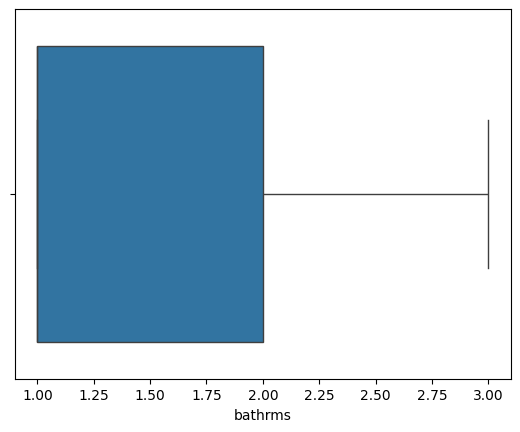

In [29]:
df.drop(outlier.index, inplace=True)
sns.boxplot(x = 'bathrms', data = df)
plt.show()

In [30]:
df.columns

Index(['price', 'lotsize', 'bedrooms', 'bathrms', 'stories', 'driveway',
       'recroom', 'fullbase', 'gashw', 'airco', 'garagepl', 'prefarea'],
      dtype='object')

In [31]:
# x = ['lotsize','bathrms','airco']
x = df[['lotsize','bathrms','airco']]
y = df.price

from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train = train_test_split(x, y,test_size=0.2,random_state=1,shuffle=True)

In [32]:
# Building the machine_learning model....
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [33]:
y_pred = lr.predict(x_test)
y_pred

array([ 76950.40425569,  81867.81146988,  86756.19962162,  90290.0817498 ,
       105085.96197127,  41354.93087672, 100248.84728348,  51911.22234242,
        47722.85009511, 105085.96197127,  74691.86651796,  67105.45318525,
        46220.49918032,  83461.21395527,  86756.19962162,  90170.63351888,
        75943.82561362, 109291.46334356,  86288.82400921,  83898.72028113,
        48952.04629813,  54187.51160727,  52195.75850053,  64777.89045646,
        49976.37646731,  59337.55911348,  94854.77803892, 127279.78230348,
        88201.64330479,  78220.11487846, 104516.88965506,  48781.32460327,
       103720.18841237, 108380.94763762,  41531.34329474, 107362.25123611,
        62313.86428275, 101671.52807401,  59878.23476937,  68192.32435372,
        46448.1281068 ,  45708.33409573, 115898.33597927,  97688.02186053,
        47586.27273922, 108244.31332624,  62057.72478497,  52138.85126891,
        96834.41338622,  48952.04629813,  48496.78844516,  93704.51564706,
        50488.5415519 ,  

In [35]:
lr.score(x_train,y_train)

0.5035615968000651

In [36]:
lr.score(x_test,y_test)

0.5238368394388497

In [37]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.5238368394388497

In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

13896.15743860005
330676012.9065062
